# Prophet – AirPassengers (Minimalversion)

**Ziel:** Monatliche Passagierzahlen (1949–1960) vorhersagen – in 5 Blöcken.

1. Daten ins Prophet-Format bringen
2. Hinschauen
3. Fitten & Komponenten prüfen
4. Prognose gegen echte Werte halten
5. Residuenanalyse

## 1 – Daten ins Prophet-Format

Prophet erwartet genau zwei Spalten: `ds` (datetime) und `y` (numerisch).

AirPassengers ist ein sauberer Datensatz: keine fehlenden Werte, bereits monatlich, keine Vorverarbeitung nötig.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import logging; logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

df_raw = pd.read_csv("AirPassengers.csv")
df = pd.DataFrame({
    "ds": pd.to_datetime(df_raw["Month"]),
    "y":  df_raw["Passengers"].astype(float),
})
print(f"{len(df)} Zeilen, {df['y'].isna().sum()} fehlend")
df.head()

d:\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


144 Zeilen, 0 fehlend


,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


## 2 – Hinschauen

Drei Konfigurationsfragen:

- **Trend?** → Klar steigend → `growth='linear'`
- **Amplitude wächst mit dem Niveau?** → Ja, deutlich! Sommer-Winter-Spanne 1949 ≈ 40, 1960 ≈ 200 → `seasonality_mode='multiplicative'`
- **Saisonalität?** → Starker Jahreszyklus (Sommerferien-Peak)

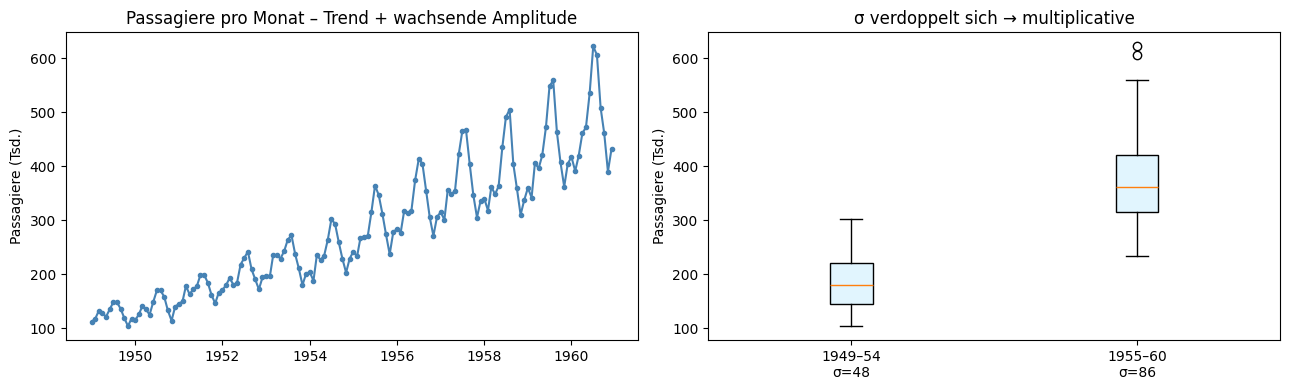

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df["ds"], df["y"], "o-", color="steelblue", markersize=3)
axes[0].set_title("Passagiere pro Monat – Trend + wachsende Amplitude")
axes[0].set_ylabel("Passagiere (Tsd.)")

# Varianzvergleich: 1. vs. 2. Hälfte
h = len(df) // 2
axes[1].boxplot(
    [df["y"].iloc[:h], df["y"].iloc[h:]],
    tick_labels=[f"1949–54\nσ={df['y'].iloc[:h].std():.0f}",
                 f"1955–60\nσ={df['y'].iloc[h:].std():.0f}"],
    patch_artist=True,
    boxprops=dict(facecolor="#e1f5fe"),
)
axes[1].set_title("σ verdoppelt sich → multiplicative")
axes[1].set_ylabel("Passagiere (Tsd.)")

plt.tight_layout(); plt.show()

## 3 – Train/Test-Split, Modell fitten, Komponenten prüfen

Letzte 24 Monate zurückhalten (2 volle Jahreszyklen). `seasonality_mode='multiplicative'` ist hier die zentrale Entscheidung – **das** Lehrbuchbeispiel für diesen Modus.

`plot_components()` zeigt Trend und Jahressaison getrennt.

09:27:30 - cmdstanpy - INFO - Chain [1] start processing


Training: 120 Monate, Test: 24 Monate


09:27:31 - cmdstanpy - INFO - Chain [1] done processing


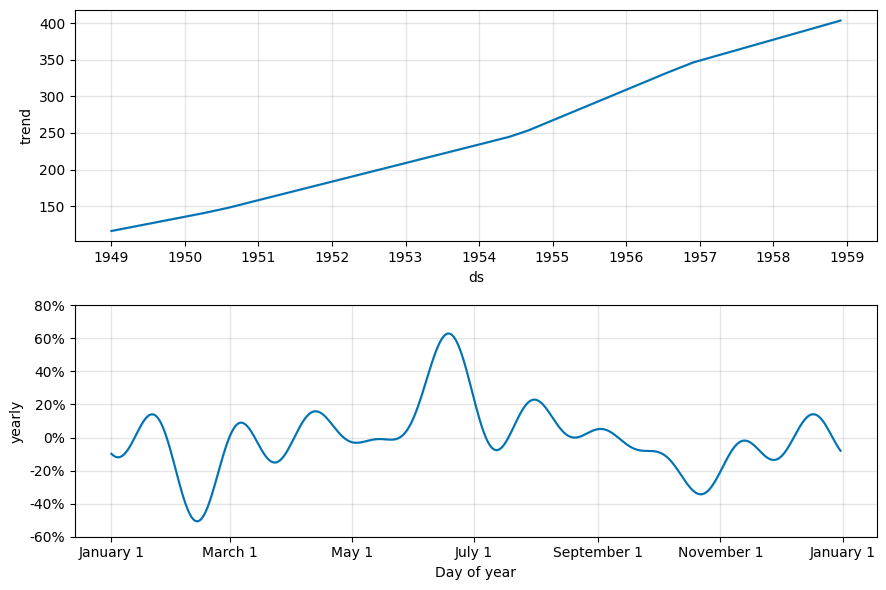

In [3]:
schnitt = df["ds"].max() - pd.DateOffset(months=24)
df_train, df_test = df[df["ds"] <= schnitt], df[df["ds"] > schnitt]
print(f"Training: {len(df_train)} Monate, Test: {len(df_test)} Monate")

modell = Prophet(
    seasonality_mode="multiplicative",  # ← Amplitude wächst mit Trend
).fit(df_train)

modell.plot_components(modell.predict(df_train))
plt.show()

## 4 – Prognose & Vergleich mit der Realität

24 Monate in die Zukunft, dann gegen die echten Testwerte halten.

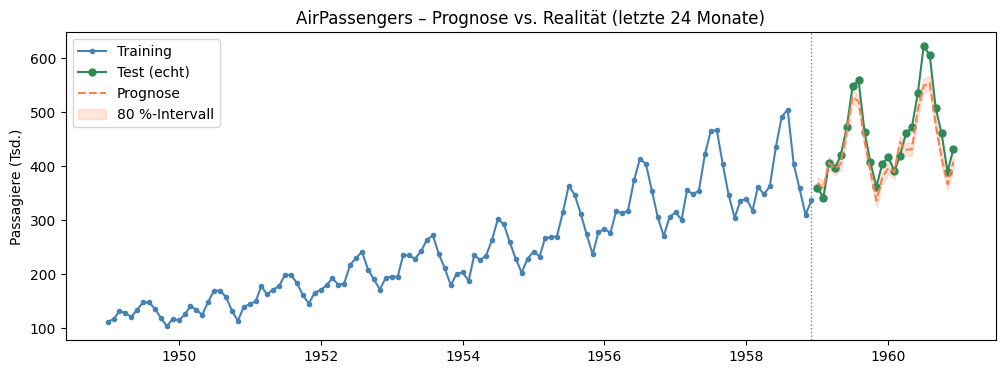

MAE  = 24.6 Passagiere
RMSE = 29.6 Passagiere
MAPE = 5.2%


In [4]:
future = modell.make_future_dataframe(periods=24, freq="MS")
forecast = modell.predict(future)

fc = forecast[forecast["ds"] > schnitt]

plt.figure(figsize=(12, 4))
plt.plot(df_train["ds"], df_train["y"], "o-", color="steelblue",
         markersize=3, label="Training")
plt.plot(df_test["ds"], df_test["y"], "o-", color="seagreen",
         markersize=5, label="Test (echt)")
plt.plot(fc["ds"], fc["yhat"], "--", color="coral", label="Prognose")
plt.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"],
                 color="coral", alpha=0.2, label="80 %-Intervall")
plt.axvline(schnitt, color="gray", linestyle=":", linewidth=1)
plt.title("AirPassengers – Prognose vs. Realität (letzte 24 Monate)")
plt.ylabel("Passagiere (Tsd.)"); plt.legend(); plt.show()

# Metriken
v = fc[["ds", "yhat"]].merge(df_test, on="ds").dropna()
e = v["y"] - v["yhat"]
print(f"MAE  = {e.abs().mean():.1f} Passagiere")
print(f"RMSE = {(e**2).mean()**0.5:.1f} Passagiere")
print(f"MAPE = {(e.abs() / v['y']).mean():.1%}")

## 5 – Residuenanalyse

Residuen $r = y - \hat{y}$ sollten wie zufälliges Rauschen aussehen.

Links: Zeitverlauf (erwartet um 0 streuend). Rechts: Gruppierung nach Monat (erwartet flach, weil Jahressaison aktiv).

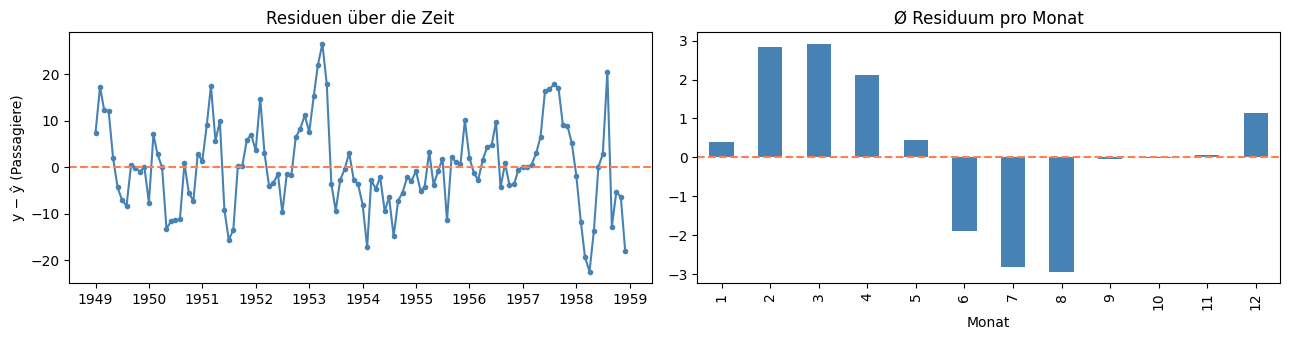

In [5]:
pred_train = modell.predict(df_train)
res = (df_train.set_index("ds")["y"] - pred_train.set_index("ds")["yhat"]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

axes[0].plot(res.index, res.values, "o-", color="steelblue", markersize=3)
axes[0].axhline(0, color="coral", linestyle="--")
axes[0].set_title("Residuen über die Zeit")
axes[0].set_ylabel("y − ŷ (Passagiere)")

res.groupby(res.index.month).mean().plot(
    kind="bar", ax=axes[1], color="steelblue"
)
axes[1].axhline(0, color="coral", linestyle="--")
axes[1].set_title("Ø Residuum pro Monat")
axes[1].set_xlabel("Monat")

plt.tight_layout(); plt.show()

## Bonus – Was passiert bei additive?

Zum Vergleich: dasselbe Modell mit `seasonality_mode='additive'`. Die Prognose wird am Ende systematisch daneben liegen, weil additive die wachsende Amplitude nicht abbilden kann.

09:27:57 - cmdstanpy - INFO - Chain [1] start processing
09:27:57 - cmdstanpy - INFO - Chain [1] done processing


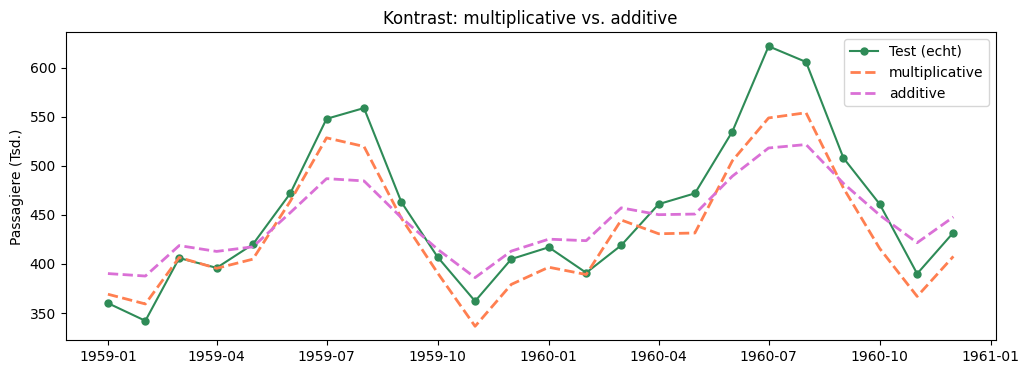

MAPE multiplicative = 5.2%
MAPE additive       = 6.5%


In [6]:
modell_add = Prophet(seasonality_mode="additive").fit(df_train)
fc_add = modell_add.predict(future)
fc_add = fc_add[fc_add["ds"] > schnitt]

plt.figure(figsize=(12, 4))
plt.plot(df_test["ds"], df_test["y"], "o-", color="seagreen",
         markersize=5, label="Test (echt)")
plt.plot(fc["ds"], fc["yhat"], "--", color="coral",
         linewidth=2, label="multiplicative")
plt.plot(fc_add["ds"], fc_add["yhat"], "--", color="orchid",
         linewidth=2, label="additive")
plt.title("Kontrast: multiplicative vs. additive")
plt.ylabel("Passagiere (Tsd.)"); plt.legend(); plt.show()

# MAPE-Vergleich
v_add = fc_add[["ds", "yhat"]].merge(df_test, on="ds").dropna()
e_add = v_add["y"] - v_add["yhat"]
print(f"MAPE multiplicative = {(e.abs() / v['y']).mean():.1%}")
print(f"MAPE additive       = {(e_add.abs() / v_add['y']).mean():.1%}")